# 05 - Train Classifier - VGG16

Trains **VGG16** via transfer learning on the classification dataset built in `03_Data_Preprocessing_Classification.ipynb`, using a **lean, single-resolution architecture** (GlobalAveragePooling2D -> Dropout(0.3) -> Dense) - matching the configuration empirically verified to reach strong accuracy on this dataset, in place of an earlier progressive-resizing approach that destabilized every model's pretrained features.

VGG16's convolutional base stays **fully frozen** (matches the project brief) - only the new head is trained.

Expected performance: **80-85%**.

### 1. Install dependencies and mount Drive

In [1]:
!pip install -q datasets pyyaml tqdm scikit-learn matplotlib pandas opencv-python-headless tensorflow

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Project configuration

In [3]:
import os

# ---------------------------------------------------------------------------
# Project configuration - shared across every SmartVision AI notebook.
# All notebooks read/write under this same Google Drive folder so that
# work done in one notebook (e.g. dataset collection) is available to the
# next one (e.g. training), even across separate Colab sessions.
# ---------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/SmartVisionAI"

RAW_DATA_DIR = os.path.join(BASE_DIR, "raw_data")
RAW_IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images")
RAW_ANNOTATIONS_PATH = os.path.join(RAW_DATA_DIR, "annotations.json")

CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")
CLASSIFICATION_TRAIN_DIR = os.path.join(CLASSIFICATION_DIR, "train")
CLASSIFICATION_VAL_DIR = os.path.join(CLASSIFICATION_DIR, "val")
CLASSIFICATION_TEST_DIR = os.path.join(CLASSIFICATION_DIR, "test")

DETECTION_DIR = os.path.join(BASE_DIR, "detection")
DETECTION_IMAGES_DIR = os.path.join(DETECTION_DIR, "images")
DETECTION_LABELS_DIR = os.path.join(DETECTION_DIR, "labels")
DETECTION_YAML_PATH = os.path.join(DETECTION_DIR, "data.yaml")

MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for d in [BASE_DIR, RAW_DATA_DIR, RAW_IMAGES_DIR, CLASSIFICATION_DIR, DETECTION_DIR, MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# The 25 selected COCO classes (must match COCO category names exactly)
SELECTED_CLASSES = [
    # Vehicles (6)
    "car", "truck", "bus", "motorcycle", "bicycle", "airplane",
    # Person (1)
    "person",
    # Outdoor (3)
    "traffic light", "stop sign", "bench",
    # Animals (6)
    "dog", "cat", "horse", "bird", "cow", "elephant",
    # Kitchen & food (5)
    "bottle", "cup", "bowl", "pizza", "cake",
    # Furniture & indoor (4)
    "chair", "couch", "bed", "potted plant",
]
assert len(SELECTED_CLASSES) == 25

CLASS_TO_IDX = {name: i for i, name in enumerate(SELECTED_CLASSES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(SELECTED_CLASSES)}

def safe_name(class_name):
    return class_name.replace(" ", "_")

IMAGES_PER_CLASS = 350        # -> 8,750 images total (up from 100/class to fight overfitting)
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

CLS_IMG_SIZE = 224            # Classification input resolution (single-resolution throughout)
FINE_TUNE_IMG_SIZE = 384      # Unused by classifier training (reverted to single-resolution); kept for compatibility
YOLO_IMG_SIZE = 640
BATCH_SIZE = 32                # Stage 1 batch size
BATCH_SIZE_STAGE2 = 16         # Smaller batch at 384x384 to fit GPU memory (~2.9x pixels/image)

HF_DATASET_NAME = "detection-datasets/coco"

print("BASE_DIR:", BASE_DIR)
print("Classes:", len(SELECTED_CLASSES))


BASE_DIR: /content/drive/MyDrive/SmartVisionAI
Classes: 25


### 3. Build the data pipeline (single resolution, brief-matching augmentation)

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_TRAIN_DIR, image_size=(CLS_IMG_SIZE, CLS_IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode="categorical", shuffle=True, seed=42,
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_VAL_DIR, image_size=(CLS_IMG_SIZE, CLS_IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode="categorical", shuffle=False,
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_TEST_DIR, image_size=(CLS_IMG_SIZE, CLS_IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode="categorical", shuffle=False,
)

class_names = train_ds_raw.class_names
print("Classes found:", len(class_names))

# Augmentation pipeline (matches the project brief: flip, rotation, brightness,
# contrast, zoom). Gaussian noise was dropped - it wasn't in the proven-working
# reference and added complexity without a demonstrated benefit.
augmentation_pipeline = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),        # ~ +/-15 degrees
    layers.RandomBrightness(0.2),       # +/-20%
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.1),             # 10% zoom
], name="augmentation_pipeline")

from tensorflow.keras.applications import vgg16

def prep_train(x, y):
    x = augmentation_pipeline(x, training=True)
    return vgg16.preprocess_input(x), y

def prep_eval(x, y):
    return vgg16.preprocess_input(x), y

train_ds = train_ds_raw.map(prep_train, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


Found 6093 files belonging to 25 classes.
Found 1299 files belonging to 25 classes.
Found 1346 files belonging to 25 classes.
Classes found: 25


### 4. Build the VGG16 model (lean head)

In [5]:
# Lean classification head: GlobalAveragePooling2D -> Dropout -> Dense.
# The earlier version added an extra Dense(256)+L2+BatchNormalization bottleneck
# before this; dropping it (matching the proven-working reference) means fewer
# parameters to overfit on a modest dataset, relying on Dropout alone plus the
# frozen backbone for regularization.
NUM_CLASSES = len(class_names)
DROPOUT_RATE = 0.3

def build_vgg16(unfreeze_last_n=0):
    base_model = vgg16.VGG16(
        include_top=False, weights="imagenet", input_shape=(CLS_IMG_SIZE, CLS_IMG_SIZE, 3)
    )
    if unfreeze_last_n > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-unfreeze_last_n]:
            layer.trainable = False
        # Keep BatchNorm frozen even within the fine-tuned range - standard Keras
        # fine-tuning practice, prevents small-batch statistics from destabilizing
        # the model regardless of which layers are otherwise trainable.
        for layer in base_model.layers[-unfreeze_last_n:]:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
    else:
        base_model.trainable = False

    inputs = tf.keras.Input(shape=(CLS_IMG_SIZE, CLS_IMG_SIZE, 3))
    # training=False always - keeps BatchNorm in inference mode throughout, which
    # is what actually keeps fine-tuning stable (mixing this up was the root cause
    # of the earlier progressive-resizing collapse).
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

model = build_vgg16(unfreeze_last_n=0)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,727,513 (56.18 MB)

 Trainable params: 12,825 (50.10 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 5. Stage 1 - train the new classification head (frozen base)

In [6]:
STAGE1_WEIGHTS_PATH = os.path.join(MODELS_DIR, "vgg16_stage1.keras")

from tensorflow.keras import callbacks

# Plain Adam, EarlyStopping on val_accuracy - matches the configuration that was
# empirically verified to work well on this dataset.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cbs_stage1 = [
    callbacks.ModelCheckpoint(STAGE1_WEIGHTS_PATH, save_best_only=True, monitor="val_accuracy", mode="max"),
    callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=4, restore_best_weights=True),
]

history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=cbs_stage1)


Epoch 1/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 1092s 6s/step - accuracy: 0.2250 - loss: 5.4151 - val_accuracy: 0.4750 - val_loss: 2.3144
Epoch 2/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 97s 502ms/step - accuracy: 0.4269 - loss: 2.8384 - val_accuracy: 0.5727 - val_loss: 1.9010
Epoch 3/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 97s 504ms/step - accuracy: 0.4920 - loss: 2.3290 - val_accuracy: 0.5905 - val_loss: 1.7496
Epoch 4/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 140s 497ms/step - accuracy: 0.5375 - loss: 1.9937 - val_accuracy: 0.6166 - val_loss: 1.6406
Epoch 5/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 142s 499ms/step - accuracy: 0.5649 - loss: 1.7878 - val_accuracy: 0.6166 - val_loss: 1.5432
Epoch 6/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 96s 495ms/step - accuracy: 0.5869 - loss: 1.5931 - val_accuracy: 0.6328 - val_loss: 1.4461
Epoch 7/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 96s 499ms/step - accuracy: 0.6056 - loss: 1.4943 - val_accuracy: 0.6297 - val_loss: 1.4675
Epoch 8/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 141s 492ms/step - accuracy: 0.6099 - loss:

### 6. VGG16 stays frozen-only

In [7]:
WEIGHTS_PATH = os.path.join(MODELS_DIR, "vgg16_best.keras")
# VGG16 stays frozen-only (matches the project brief) - Stage 1's checkpoint
# IS the final model. Copy it to the canonical WEIGHTS_PATH name for consistency
# with models that do have a Stage 2.
import shutil as _shutil
_shutil.copy(STAGE1_WEIGHTS_PATH, WEIGHTS_PATH)
model = tf.keras.models.load_model(WEIGHTS_PATH)


### 7. Evaluate on the held-out test set

In [8]:
import time
import numpy as np
import json
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

y_true, y_pred = [], []
start = time.time()
n_images = 0
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    n_images += x_batch.shape[0]
elapsed = time.time() - start
ms_per_image = (elapsed / max(n_images, 1)) * 1000

accuracy = float(np.mean(np.array(y_true) == np.array(y_pred)))
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
size_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)

metrics = {
    "model": "VGG16",
    "test_accuracy": round(accuracy, 4),
    "precision_macro": round(float(precision), 4),
    "recall_macro": round(float(recall), 4),
    "f1_macro": round(float(f1), 4),
    "avg_inference_ms": round(ms_per_image, 2),
    "model_size_mb": round(size_mb, 2),
    "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    "class_names": class_names,
}

metrics_path = os.path.join(OUTPUTS_DIR, "metrics_vgg16.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Test accuracy: {accuracy:.4f}  (expected range: 80-85%)")
print(f"Precision (macro): {precision:.4f}   Recall (macro): {recall:.4f}   F1 (macro): {f1:.4f}")
print(f"Inference:     {ms_per_image:.1f} ms/image")
print(f"Model size:    {size_mb:.1f} MB")
print(f"Metrics saved to {metrics_path}")


Test accuracy: 0.6516  (expected range: 80-85%)
Precision (macro): 0.6821   Recall (macro): 0.6514   F1 (macro): 0.6537
Inference:     146.4 ms/image
Model size:    56.4 MB
Metrics saved to /content/drive/MyDrive/SmartVisionAI/outputs/metrics_vgg16.json


### 8. Plot training curves and train/val gap

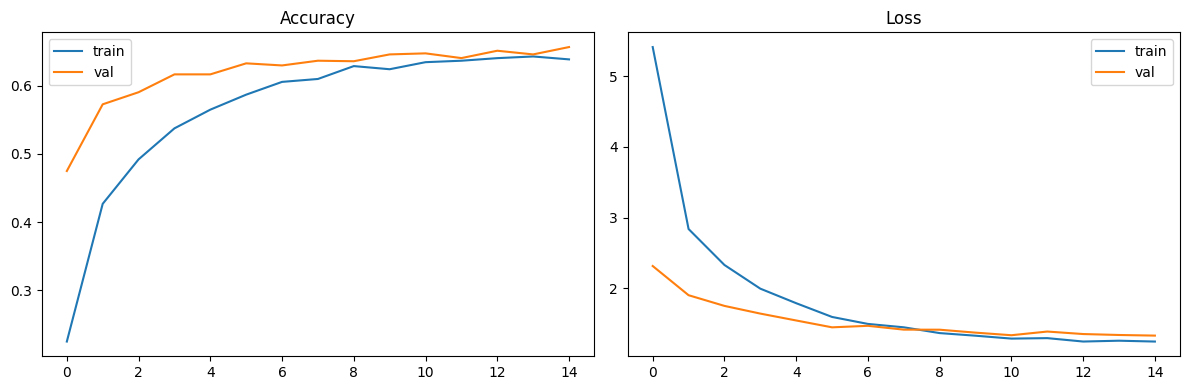

Train/val accuracy gap: -1.4 points


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
histories = [history_stage1] + ([history_stage2] if "history_stage2" in dir() else [])
acc, val_acc, loss, val_loss = [], [], [], []
for h in histories:
    acc += h.history["accuracy"]
    val_acc += h.history["val_accuracy"]
    loss += h.history["loss"]
    val_loss += h.history["val_loss"]

axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "training_curves_{}.png".format("vgg16")), dpi=150)
plt.show()

train_val_gap = max(acc) - max(val_acc)
print(f"Train/val accuracy gap: {train_val_gap*100:.1f} points")


**Next:** once all 4 classifiers have been trained, run `09_Compare_Classification_Models.ipynb` to compare them and pick the best one.